In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Howell1.csv")
df = df[df["age"] >= 18]
df

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
534,162.560,47.031821,27.0,0
537,142.875,34.246196,31.0,0
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0


In [3]:
model = pm.Model()

with model:
    sigma = pm.Uniform("sigma", lower=0, upper=50)
    mu = pm.Normal("mu", mu=178, sigma=20)
    height = pm.Normal("height", mu=mu, sigma=sigma, observed=df["height"])
    idata = pm.sample()

az.summary(idata)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,154.604,0.418,153.835,155.376,0.007,0.007,3864.0,2829.0,1.0
sigma,7.775,0.296,7.218,8.334,0.005,0.004,3740.0,3140.0,1.0


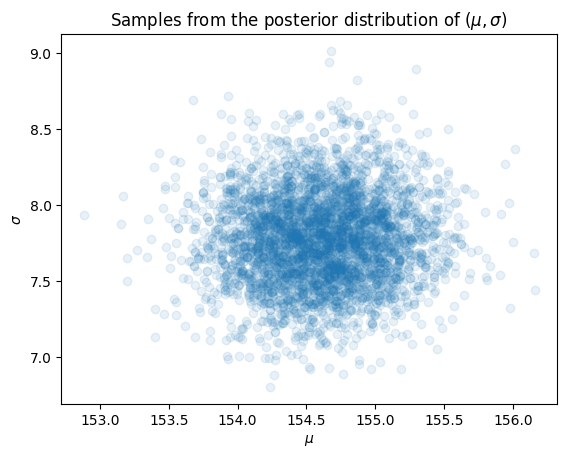

In [4]:
mu_post = idata["posterior"]["mu"].to_numpy().ravel()
sigma_post = idata["posterior"]["sigma"].to_numpy().ravel()
plt.scatter(mu_post, sigma_post, alpha=0.1)
plt.title("Samples from the posterior distribution of $(\\mu, \\sigma)$")
plt.xlabel("$\\mu$")
plt.ylabel("$\\sigma$")
plt.show()

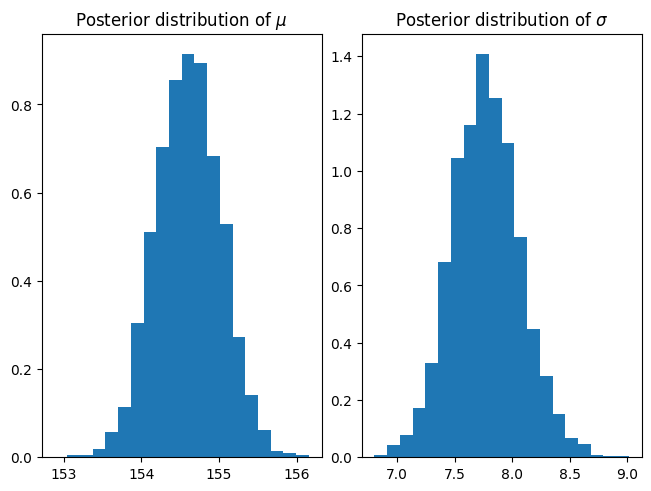

In [5]:
fig, (a0, a1) = plt.subplots(nrows=1, ncols=2, layout="constrained")
a0.hist(mu_post, bins=20, density=True)
a0.set_title("Posterior distribution of $\\mu$")
a1.hist(sigma_post, bins=20, density=True)
a1.set_title("Posterior distribution of $\\sigma$")
plt.show()

In [6]:
mu_post.mean(), df["height"].mean()

(np.float64(154.60409939375606), np.float64(154.5970926136364))

In [7]:
mu_post.std(), df["height"].std() / np.sqrt(len(df))

(np.float64(0.4183799095286503), np.float64(0.4126676894866274))

In [8]:
sigma_post.mean(), df["height"].std()

(np.float64(7.775409073005834), np.float64(7.742332137351995))

<Axes: xlabel='weight', ylabel='height'>

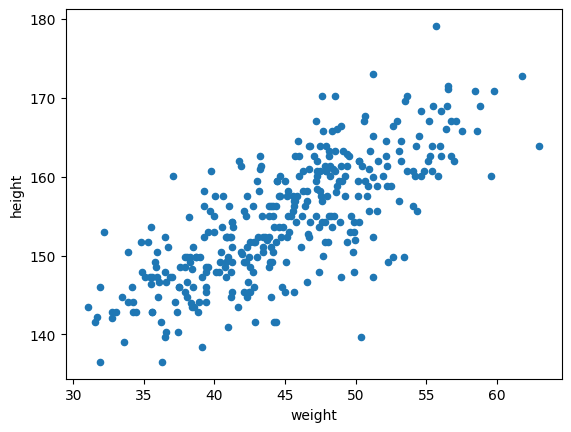

In [9]:
df.plot.scatter("weight", "height")

### &sect;4.4 Linear Prediction

In [ ]:
model = pm.Model()

H = df["height"]
W = df["weight"]

with model:
    sigma = pm.Uniform("sigma", lower=0, upper=50)
    alpha = pm.Normal("alpha", mu=178, sigma=20)
    beta = pm.Normal("beta", mu=0, sigma=10)
    mu = alpha + beta * (W - W.mean())
    height = pm.Normal("height", mu=mu, sigma=sigma, observed=H)
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [11]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,154.601,0.270,154.084,155.102,0.003,0.004,6663.0,3328.0,1.0
beta,0.905,0.043,0.824,0.984,0.001,0.001,7012.0,3155.0,1.0
sigma,5.109,0.192,4.767,5.490,0.002,0.003,7173.0,3062.0,1.0
